# Chapter 24: Cellular Automata with DisSModel

*Part IV — DisSModel: Core and Paradigms*

Implemented by the [`dissmodel-ca`](https://github.com/DisSModel/dissmodel-ca) package.

> **Live demo:** try the models in this chapter directly in the browser — [dissmodel-ca-demo on Hugging Face Spaces](https://huggingface.co/spaces/profsergiocosta/dissmodel-ca-demo).

## Learning Objectives

By the end of this chapter you will be able to:

- Go beyond Chapter 22's Game of Life teaser into the full `dissmodel-ca` model library
- Compare TerraME Lua cellular automata to their DisSModel equivalents, rule for rule
- Restore the `empty` state the `FireModel` port left out, and measure the percolation threshold it produces
- Measure the vector-vs-raster performance gap, and show that it comes from per-cell Python, not from the substrate

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Chapter 23 showed that DisSModel's lifecycle isn't inherently spatial. This chapter is the opposite case: cellular automata are the paradigm where space *is* the model — every cell's next state depends only on itself and its neighbors, with no central controller anywhere in the equations. Chapter 22's Game of Life was a first taste; `dissmodel-ca` is a full library built on that same idea.

## The dissmodel-ca Package

`dissmodel-ca` ships sixteen models in `src/dissmodel_ca/models/`, all built on the same `CellularAutomaton` base class — thirteen distinct automata, two of them (`GameOfLife`, `FireModel`) shipped twice, once against `CellularAutomaton` (`self.gdf`) and once against `RasterCellularAutomaton` (`self.backend`) — the exact substrate choice Chapter 22 introduced, made concrete as two working files instead of one:

| `dissmodel_ca.models` | TerraME `ca` (`lua/`) | What it models |
|---|---|---|
| `game_of_life.GameOfLife` | `Life.lua` | Conway's Game of Life (vector) |
| `game_of_life_raster.GameOfLife` | `Life.lua` | Same rule, `RasterCellularAutomaton` |
| `fire_model.FireModel` | `Fire.lua` | Forest fire spread (vector) |
| `fire_model_raster.FireModel` | `Fire.lua` | Same rule, `RasterCellularAutomaton` |
| `fire_model_prob.FireModelProb` | — | Fire spread, probabilistic ignition (DisSModel-only) |
| `anneal.Anneal` | `Anneal.lua` | Majority-vote binary relaxation |
| `propagation.Propagation` | — | Stochastic ON/OFF spatial propagation (DisSModel-only) |
| `solid_diffusion.SolidDiffusion` | `SolidDiffusion.lua` | Vacancy-mechanism atomic diffusion |
| `snow.Snow` | `Snow.lua` | Snowfall and accumulation |
| `excitable.Excitable` | `Excitable.lua` | Excitable-medium spiral/ring waves |
| `growth.Growth` | `Growth.lua` | Stochastic radial growth from a seed |
| `parasit.Parasit` | `Parasit.lua` | Host-parasite spatial dynamics |
| `wolfram.Wolfram` | `Wolfram.lua` | 1D elementary CA (Wolfram's rules) |
| `interspecific_competition.InterspecificCompetition` | `InterspecificCompetition.lua` | Grass-species spatial competition |
| `oscillator.Oscillator` | `Oscillator.lua` | Oscillator CA rule |
| `parity.Parity` | `Parity.lua` | Parity (Gilbert) CA rule |

Three of TerraME's own `ca` models — `BandedVegetation.lua`, `DaisyWorld.lua` (a spatial variant distinct from `dissmodel-sysdyn`'s non-spatial `Daisyworld`), and `Influenza.lua` — have no DisSModel port yet; `propagation.Propagation` and `fire_model_prob.FireModelProb` go the other way, DisSModel-only additions with no Lua original.

Every model in this table implements the same contract: a `rule(idx)` method (or, for the two raster variants, a `rule(arrays)` operating on the whole grid at once) deciding a cell's next state from its neighbors, applied automatically each tick by `execute()`. That shared shape is also what makes the package's Streamlit explorer possible without listing models by hand — auto-discovery works precisely because every concrete subclass looks the same from the outside.

This chapter works through two in real depth — `GameOfLife` and `FireModel` below — chosen because their TerraME originals are the two most-cited textbook automata, not because the other eleven are less real. The package's own notebooks in `examples/notebooks/` are the place to see the rest.

## Theory: What Is a Cellular Automaton

Chapter 23's system dynamics models treated a whole stock as one undifferentiated block — no spatial structure at all. Cellular automata exist to add exactly that: a grid of autonomous cells, each changing state based only on its own state and its neighbors', with no cell able to see the whole grid at once.

Cellular automata were proposed by John von Neumann — the same von Neumann of computer architecture — while searching for a model of logical systems capable of self-replication. Every cellular automaton, however different the phenomenon it models, is defined by six elements: a grid of cells, a neighborhood, a finite set of discrete states, a finite set of transition rules, an initial state, and discrete time.

Two neighborhood shapes recur throughout this chapter, and both should already be familiar: **Von Neumann** (4 orthogonal neighbors) and **Moore** (all 8 surrounding cells, diagonals included) — in `dissmodel-ca` these map directly onto `Rook` and `Queen`, the exact contiguity definitions Chapter 10 built by hand.

### Synchronization, Made Implicit

TerraME kept two copies of every `CellularSpace` — one holding *past* values, one holding *present* values — because every rule had to read the past copy while writing the present one, or cells updated in different order within the same tick would see an inconsistent mix of old and new state. `CellularAutomaton.rule(idx)` achieves the same consistency without ever naming a `past` attribute: `execute()` reads the state consolidated at the *end* of the previous tick, for every cell, before writing any new one. The synchronization TerraME made an explicit, named concept, DisSModel gets for free from the order `execute()` already runs in.

### GameOfLife: TerraME vs DisSModel

Conway's rule — die below 2 or above 3 live neighbors, survive at exactly 2 or 3, come alive at exactly 3 — is identical in both languages. `Life.lua` builds its neighborhood with `wrap = true` (a toroidal grid, where edges connect to the opposite side); `GameOfLife` does not enable wrap by default, so behavior differs at the grid boundary specifically, not the interior — worth checking before porting a TerraME model that depends on a toroidal edge.

**Definition** — Conway's rule, cell for cell:

```lua
-- Life.lua (TerraME)
Life = Model{
	finalTime = 100,
	dim = 30,
	init = function(model)
		model.cell = Cell{
			init = function(cell) cell.state = "dead" end,
			execute = function(cell)
				local alive = countNeighbors(cell, "alive")
				if alive < 2 then
					cell.state = "dead"
				elseif alive > 3 then
					cell.state = "dead"
				elseif alive == 3 and cell.past.state == "dead" then
					cell.state = "alive"
				end
			end
		}
		model.cs = CellularSpace{xdim = model.dim, instance = model.cell}
		model.cs:createNeighborhood{wrap = true}  -- toroidal
		-- ...Map wired to state -- see "Execution" below
	end
}
```

The DisSModel translation, defined here and actually run in this kernel — not just described:

In [2]:
from libpysal.weights import Queen
from dissmodel.geo import CellularAutomaton


class GameOfLife(CellularAutomaton):
    def setup(self):
        self.create_neighborhood(strategy=Queen, use_index=True)

    def rule(self, idx):
        state = self.gdf.loc[idx, self.state_attr]
        live_neighbors = (self.neighbor_values(idx, self.state_attr)).sum()

        if state == 1:
            return 1 if 2 <= live_neighbors <= 3 else 0
        return 1 if live_neighbors == 3 else 0


**Execution** — TerraME CA models run themselves, no separate scenario file: construct with parameters, call `:execute()`, save the map:

```lua
-- life.lua (TerraME)
import("ca")

life = Life{finalTime = 15}
life:execute()
life.map:save("life.bmp")
```

The code cell below is the equivalent DisSModel shape — `vector_grid()` for the substrate, `GameOfLife(gdf=...)`, `env.run()` — except `Map`/`Chart` are separate components attached to the same `Environment`, not built into the model's own `init()`.

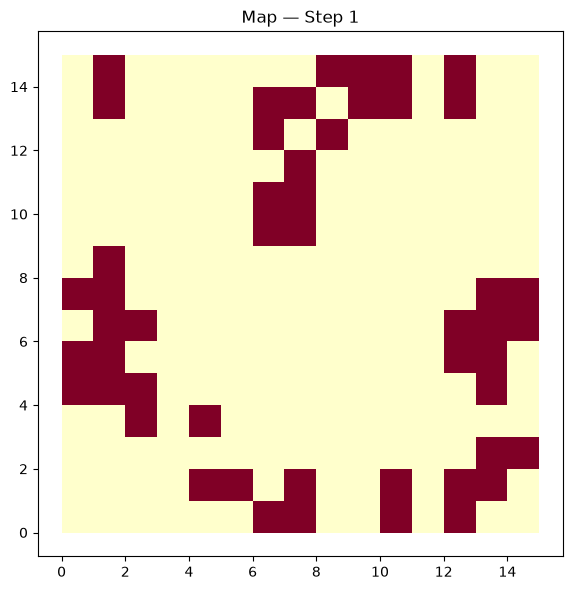

Alive after one tick: 50


In [3]:
from dissmodel.core import Environment
from dissmodel.geo import vector_grid
from dissmodel_ca.models import GameOfLife
from dissmodel.visualization import Map

gdf = vector_grid(dimension=(15, 15), resolution=1, attrs={"state": 0})
env = Environment(start_time=0, end_time=1)
gol = GameOfLife(gdf=gdf)
gol.initialize()
print("Alive before:", int(gdf["state"].sum()))
Map(gdf=gdf, plot_params={"column": "state", "cmap": "YlOrRd", "legend": False})
env.run()
print("Alive after one tick:", int(gdf["state"].sum()))

## Case Study: Fire in the Forest

`FireModel` is the classic first full application of the six CA elements above: a `FOREST` / `BURNING` / `BURNED` state space, a Rook (Von Neumann) neighborhood, and one rule — a `FOREST` cell catches fire if any neighbor is `BURNING`; a `BURNING` cell becomes `BURNED` after exactly one tick:

**Definition** — the propagation rule itself (burning → burned; forest next to fire → burning) matches TerraME's `Fire.lua` step by step. The port changes two things around it, both visible in the Lua below: `Fire.lua` has an `empty` state (10% of cells by default — the firebreaks) and ignites a single random cell (`cs:sample()`), while `FireModel` has no empty state and ignites a random fraction of cells (`initial_fire_density`). *Percolation*, near the end of the chapter, shows why the first difference matters:

```lua
-- Fire.lua (TerraME)
Fire = Model{
	finalTime = 100,
	empty = Choice{min = 0, max = 1, default = 0.1},
	dim = 60,
	init = function(model)
		model.cell = Cell{
			init = function(cell)
				if Random():number() > model.empty then
					cell.state = "forest"
				else
					cell.state = "empty"
				end
			end,
			execute = function(cell)
				if cell.past.state == "burning" then
					cell.state = "burned"
				elseif cell.past.state == "forest" then
					local burning = countNeighbors(cell, "burning")
					if burning > 0 then
						cell.state = "burning"
					end
				end
			end
		}
		model.cs = CellularSpace{xdim = model.dim, instance = model.cell}
		model.cs:sample().state = "burning"
		model.cs:createNeighborhood{strategy = "vonneumann"}  -- same as Rook
		-- ...Chart and Map wired to state -- see "Execution" below
	end
}
```

The DisSModel translation, defined here and actually run in this kernel:

In [4]:
from enum import IntEnum
from libpysal.weights import Rook
from dissmodel.geo import CellularAutomaton
from dissmodel.geo import CellularAutomaton, FillStrategy, fill

class FireState(IntEnum):
    FOREST = 0
    BURNING = 1
    BURNED = 2


class FireModel(CellularAutomaton):
    def setup(self, initial_fire_density=0.05, seed=42):
        self.initial_fire_density = initial_fire_density
        self.seed = seed
        self.create_neighborhood(strategy=Rook, use_index=True)

    def initialize(self) -> None:
        """
        Fill the grid with a random initial state.

        Uses :attr:`initial_fire_density` to determine the proportion of
        cells that start as burning. The remaining cells start as forest.
        """
        fill(
            strategy=FillStrategy.RANDOM_SAMPLE,
            gdf=self.gdf,
            attr="state",
            data={
                FireState.FOREST:  1 - self.initial_fire_density,
                FireState.BURNING: self.initial_fire_density,
            },
            seed=self.seed,
        )

    def rule(self, idx):
        state = self.gdf.loc[idx, self.state_attr]

        if state == FireState.BURNING:
            return FireState.BURNED

        if state == FireState.FOREST:
            if (self.neighbor_values(idx, self.state_attr) == FireState.BURNING).any():
                return FireState.BURNING

        return state


**Execution** — same shape as `Life` above:

```lua
-- fire.lua (TerraME)
import("ca")

fire = Fire{finalTime = 15}
fire:execute()
fire.map:save("fire.bmp")
```

In [5]:
from dissmodel_ca.models import FireModel, FireState

gdf = vector_grid(dimension=(40, 40), resolution=1, attrs={"state": 0})
env = Environment(start_time=0, end_time=30)
fire = FireModel(gdf=gdf, initial_fire_density=0.05, seed=42)
fire.initialize()

print("Initial:", gdf["state"].value_counts().to_dict())
env.run()
print("After 30 ticks:", gdf["state"].value_counts().to_dict())

Initial: {0: 1520, 1: 80}
Running from 0 to 30 (duration: 30)


After 30 ticks: {2: 1600}


Watching only the printed state counts hides where the fire actually is on the grid. Attaching a `Map` component — exactly the way Chapter 22's `GameOfLife` example did — colors each cell by its `state` and redraws it every tick, live:

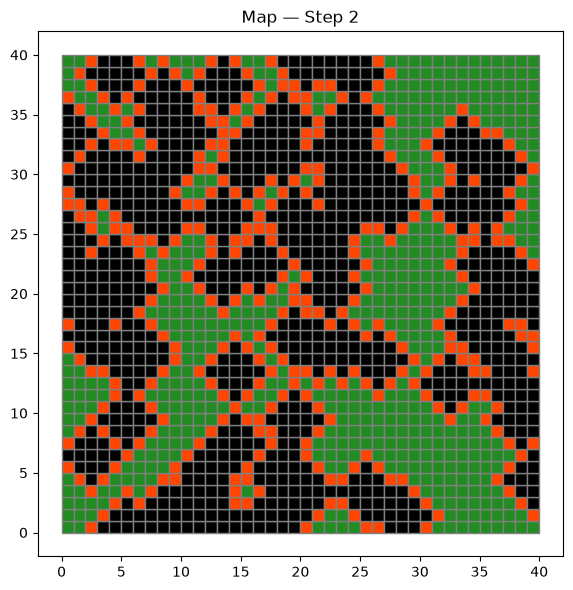

In [6]:
from dissmodel.visualization import Map
from matplotlib.colors import ListedColormap

gdf = vector_grid(dimension=(40, 40), resolution=1, attrs={"state": 0})
env = Environment(start_time=0, end_time=2)
fire = FireModel(gdf=gdf, initial_fire_density=0.05, seed=42)
fire.initialize()

cmap = ListedColormap(["forestgreen", "orangered", "black"])
Map(gdf=gdf, plot_params={"column": "state", "cmap": cmap, "ec": "gray", "vmin": 0, "vmax": 2})

env.run()

Green cells are still forest, orange cells are actively burning, black cells are already burned — a single glance at the last frame shows the fire's actual shape and reach, something the earlier cell's raw counts never could. This is the same `Map` class, called the same way, on a completely different model — the substrate-agnostic visualization Chapter 21 first introduced doesn't care which `CellularAutomaton` subclass it's attached to.

## Two More, in Brief: Anneal and Growth

`GameOfLife` and `FireModel` got the full treatment above; `Anneal` and `Growth` get the shorter comparative version — real Lua next to real Python, definition only, no live execution — the same depth the rest of the package table gets none of.

**`Anneal`** (Toffoli & Margolis, 1988) is a majority-vote relaxation rule — no growth, no spread, just cells flipping toward whatever state most of their neighbors already hold:

```lua
-- Anneal.lua (TerraME)
Anneal = Model{
	finalTime = 100, dim = 80, random = true,
	init = function(model)
		model.cell = Cell{
			state = Random{"L", "R"},
			execute = function(cell)
				local alive = countNeighbors(cell, "L")
				if cell.state == "L" then alive = alive + 1 end
				if alive <= 3 then cell.state = "R"
				elseif alive >= 6 then cell.state = "L"
				elseif alive == 4 then cell.state = "L"
				elseif alive == 5 then cell.state = "R"
				end
			end
		}
		model.cs = CellularSpace{xdim = model.dim, instance = model.cell}
		model.cs:createNeighborhood()  -- Queen, TerraME's default
		-- ...Map wired to state...
	end
}
```

```python
# anneal.py (dissmodel-ca)
def setup(self) -> None:
    self.create_neighborhood(strategy=Queen, use_index=True)

def rule(self, idx: Any) -> int:
    state = self.gdf.loc[idx, self.state_attr]

    # Count neighbors in state L, including the cell itself
    count = (self.neighbor_values(idx, self.state_attr) == AnnealState.L).sum()
    if state == AnnealState.L:
        count += 1

    if count <= 3:
        return AnnealState.R
    if count == 4:
        return AnnealState.L
    if count == 5:
        return AnnealState.R
    return AnnealState.L  # count >= 6
```

**`Growth`** seeds a single live cell at the grid's center and lets it colonize empty neighbors stochastically — the honest gap here is the neighborhood itself: TerraME's original uses `vonneumann` (4 neighbors), `dissmodel-ca`'s port uses `Queen` (8 neighbors), so the two won't produce pixel-identical clusters even from the same seed:

```lua
-- Growth.lua (TerraME)
Growth = Model{
	finalTime = 100, dim = 100, probability = 0.15, random = true,
	init = function(model)
		model.cell = Cell{
			init = function(cell)
				if cell.x == model.dim / 2 and cell.y == model.dim / 2 then
					cell.state = "alive"
				else
					cell.state = "empty"
				end
			end,
			execute = function(cell)
				local count = countNeighbors(cell, "alive")
				if cell.past.state == "empty" and count > 0
				   and Random():number() < model.probability then
					cell.state = "alive"
				end
			end
		}
		model.cs = CellularSpace{xdim = model.dim, instance = model.cell}
		model.cs:createNeighborhood{strategy = "vonneumann"}
		-- ...Map wired to state...
	end
}
```

```python
# growth.py (dissmodel-ca)
def setup(self, probability: float = 0.15) -> None:
    self.probability = probability
    self.create_neighborhood(strategy=Queen, use_index=True)  # TerraME used vonneumann

def rule(self, idx: Any) -> int:
    state = self.gdf.loc[idx, self.state_attr]

    if state == GrowthState.ALIVE:
        return GrowthState.ALIVE

    alive_neighbors = (self.neighbor_values(idx, self.state_attr) == GrowthState.ALIVE).sum()
    if alive_neighbors > 0 and random.random() < self.probability:
        return GrowthState.ALIVE

    return GrowthState.EMPTY
```

Both, like every model in the package table above, have their own notebook in `examples/notebooks/` for the full walkthrough this chapter doesn't have room for.

## Vector vs Raster: Comparing Implementations

`FireModel` ships in both forms, exactly like `GameOfLife` — same rule, same propagation logic, different substrate underneath. Timing both on the same grid and tick count makes Chapter 20's performance argument concrete instead of theoretical:

In [7]:
import time
from dissmodel.geo.raster import raster_grid
from dissmodel_ca.models import FireModelRaster

# Vector
gdf = vector_grid(dimension=(40, 40), resolution=1, attrs={"state": 0})
env = Environment(start_time=0, end_time=30)
fire_vec = FireModel(gdf=gdf, initial_fire_density=0.01, seed=1)
fire_vec.initialize()
initial_state = gdf["state"].to_numpy().copy()  # kept for the comparison below
start = time.perf_counter()
env.run()
vector_ms = (time.perf_counter() - start) * 1000
vector_final = gdf["state"].to_numpy().copy()

# Raster
backend = raster_grid(rows=40, cols=40, attrs={"state": 0})
env = Environment(start_time=0, end_time=30)
fire_ras = FireModelRaster(backend=backend, initial_fire_density=0.01, seed=1)
fire_ras.initialize()
start = time.perf_counter()
env.run()
raster_ms = (time.perf_counter() - start) * 1000

print(f"Vector: {vector_ms:8.1f} ms")
print(f"Raster: {raster_ms:8.1f} ms")
print(f"Raster is {vector_ms / raster_ms:.0f}x faster on this 40x40 grid, 30 ticks")

Running from 0 to 30 (duration: 30)


Running from 0 to 30 (duration: 30)
Vector:   8515.2 ms
Raster:      3.1 ms
Raster is 2741x faster on this 40x40 grid, 30 ticks


The gap is not subtle — on this grid it comes out well over a thousand times. But it is worth asking what the gap is actually made of. `FireModel.rule(idx)` runs once per cell, in pure Python, via `self.gdf.index.map(self.rule)`, and reads its neighbors through `.loc` lookups: 1,600 cells times 31 ticks of interpreter overhead. `FireModelRaster.execute()` applies the same logic to the whole grid as one array operation — the kind of whole-array computation Chapter 8 introduced and Chapter 20 argued for. The difference between them is *per-cell Python versus whole-array computation*, not geometry versus grid.

The cell below tests that claim by keeping the vector substrate — the same `GeoDataFrame`, the same Rook neighborhood — and changing only how the rule is computed. The neighborhood becomes a sparse adjacency matrix `W` (Chapter 10's weights object carries one, `.sparse`), and "does any neighbor burn?" becomes a single matrix–vector product:

In [8]:
from libpysal.weights import Rook

FOREST, BURNING, BURNED = FireState.FOREST, FireState.BURNING, FireState.BURNED


def fire_step(state, W):
    """One FireModel tick for every cell at once: count burning Rook neighbors with a sparse product."""
    burning_neighbors = W @ (state == BURNING).astype(np.int8)
    new = state.copy()
    new[state == BURNING] = BURNED
    new[(state == FOREST) & (burning_neighbors > 0)] = BURNING
    return new


W = Rook.from_dataframe(gdf, use_index=False).sparse.tocsr()  # same polygons, same neighborhood as FireModel

state = initial_state.copy()
start = time.perf_counter()
for _ in range(31):  # end_time=30 is inclusive: 31 ticks, as in the benchmark above
    state = fire_step(state, W)
sparse_ms = (time.perf_counter() - start) * 1000

print(f"Vector, per-cell rule (FireModel): {vector_ms:8.1f} ms")
print(f"Vector, sparse matrix:             {sparse_ms:8.2f} ms")
print(f"Raster (FireModelRaster):          {raster_ms:8.2f} ms")
print("Same final state as FireModel:", np.array_equal(state, vector_final))

Vector, per-cell rule (FireModel):   8515.2 ms
Vector, sparse matrix:                 1.17 ms
Raster (FireModelRaster):              3.11 ms
Same final state as FireModel: True


Same final state, cell for cell, and the vector substrate is now as fast as the raster one. The lesson reaches beyond this model: whenever a rule depends on its neighbors only through a count or a sum — fire spread, the Game of Life, majority vote, diffusion — `W @ state` evaluates it for every polygon at once, on a regular grid or on irregular municipalities alike. What the per-cell `rule(idx)` contract buys in exchange is generality: it accepts any Python a modeler cares to write, including rules no matrix product can express.

So the substrate choice is really two separate choices. Vector or raster depends on the geometry: exact, irregular polygons, or a regular grid. Per-cell or vectorized depends on the rule: full expressive freedom, or speed on large grids and many runs.

## Percolation: Putting the Empty Cells Back

`Fire.lua` has one more state than `FireModel`: `empty`, cells with nothing to burn. Without it, every forest cell on a connected grid is reachable from any spark, so the whole grid always burns — not a finding about fire, just a consequence of what the port left out. With it, the model shows **percolation**: below a critical forest density, empty cells break the forest into disconnected patches and a fire dies out near where it started; above it, one connected forest spans the grid and a fire crosses it. For site percolation on a square grid with Rook neighbors, theory puts that critical density near 0.593.

The sparse rule from the previous section makes the experiment cheap: a 60 × 60 grid (`Fire.lua`'s own `dim`), an `EMPTY` state added, the whole left edge set alight, 30 random forests per density.

forest density 0.50: 9% of the forest burns
forest density 0.56: 25% of the forest burns
forest density 0.60: 52% of the forest burns
forest density 0.64: 90% of the forest burns
forest density 0.70: 98% of the forest burns


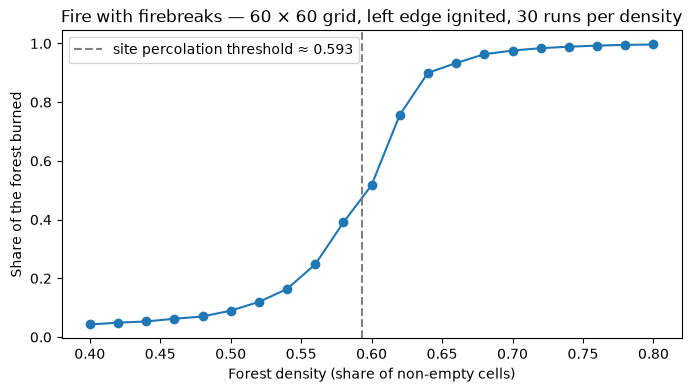

In [9]:
EMPTY = 3  # the state Fire.lua has and FireModel does not

grid60 = vector_grid(dimension=(60, 60), resolution=1, attrs={"state": 0})
W60 = Rook.from_dataframe(grid60, use_index=False).sparse.tocsr()
left_edge = (grid60.geometry.centroid.x < 1).to_numpy()


def burned_fraction(forest_density, seed):
    rng = np.random.default_rng(seed)
    state = np.where(rng.random(len(grid60)) < forest_density, FOREST, EMPTY)
    state[left_edge & (state == FOREST)] = BURNING
    n_forest = (state != EMPTY).sum()
    while (state == BURNING).any():
        state = fire_step(state, W60)  # EMPTY is never FOREST, so it never ignites
    return (state == BURNED).sum() / n_forest


densities = np.round(np.arange(0.40, 0.81, 0.02), 2)
mean_burned = np.array([np.mean([burned_fraction(p, seed) for seed in range(30)]) for p in densities])
for p in (0.50, 0.56, 0.60, 0.64, 0.70):
    print(f"forest density {p:.2f}: {mean_burned[densities == p][0]:.0%} of the forest burns")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(densities, mean_burned, marker="o")
ax.axvline(0.593, color="gray", linestyle="--", label="site percolation threshold ≈ 0.593")
ax.set_xlabel("Forest density (share of non-empty cells)")
ax.set_ylabel("Share of the forest burned")
ax.set_title("Fire with firebreaks — 60 × 60 grid, left edge ignited, 30 runs per density")
ax.legend()
plt.show()

At a forest density of 0.50, a fire lit along the whole left edge burns about 9% of the forest; at 0.64 it burns about 90%. Almost the entire switch happens inside a narrow band around the theoretical 0.593, and on a larger grid the band would be narrower still. `FireModel` cannot show any of this, and the reason is now concrete: its port dropped `Fire.lua`'s `empty` state. Adding it back to the package — a fourth `FireState` value and an `empty_density` parameter, with no change at all to the propagation rule — would restore the TerraME model's most instructive behavior.

## Exercises

1. **Rook, not Queen.** `FireModel.setup()` uses `Rook` instead of the package's more common default, `Queen`. Looking back at Chapter 10's Queen-vs-Rook distinction, explain in one sentence why a fire model specifically calls for the narrower neighborhood.
2. **Wrap the edges.** `GameOfLife`'s default neighborhood doesn't wrap at the grid boundary, unlike TerraME's `Life.lua`. Sketch — in words, no code required — what would need to change in `create_neighborhood()`'s call for wrap-around edges to be enabled.
3. **Ignite one cell, as `Fire.lua` does.** Change `burned_fraction()` so that only one random forest cell starts burning (`Fire.lua`'s `cs:sample()`) instead of the whole left edge. How does the curve change, and why does it become noisier near the threshold?
4. **Pick an unfamiliar model.** Choose one of `Anneal`, `Excitable`, `Snow`, `Growth`, `Parasit`, or `Interspecific` from the model table, install nothing new, and read its docstring alone (`help(dissmodel_ca.models.Anneal)`, for instance). Write a one-paragraph description of the phenomenon it models and which neighborhood strategy — Rook or Queen — you'd guess it relies on, before checking.

In [10]:
# Your code here

## Summary

### Key concepts introduced

- The six elements of any cellular automaton: grid, neighborhood, states, rules, initial state, discrete time
- `CellularAutomaton.rule(idx)` as the contract every model in `dissmodel-ca` implements, and why it makes DisSModel's synchronization implicit where TerraME needed an explicit `past` copy
- `dissmodel-ca`'s full sixteen-model library, mapped against TerraME's own `ca` package — thirteen direct ports (two of them, `GameOfLife` and `FireModel`, shipped twice as vector/raster pairs), two DisSModel-only additions, and three TerraME models not yet ported
- `GameOfLife` and `FireModel` in full depth — defined as real, running classes in this notebook, not just described, then executed against the maintained package — including a documented known gap (toroidal wrap not enabled by default); `Anneal` and `Growth` as shorter Lua/Python comparisons with no live execution, including a second honest gap (`Growth`'s neighborhood: `vonneumann` in TerraME, `Queen` in DisSModel)
- Percolation restored: the `FireModel` port dropped `Fire.lua`'s `empty` state; putting it back reveals the site-percolation threshold near 0.593
- A measured vector-vs-raster performance gap — and the sparse-matrix version of the same vector model, which closes it: the cost is per-cell Python, not the substrate

Chapter 25 moves from cells that only know their neighbors to agents that can move, decide, and interact — `dissmodel-abm`, built on the same `Model` foundation from Chapter 21 once again.

## Further Reading

- von Neumann, J., & Burks, A. W. (1966). *Theory of Self-Reproducing Automata*. University of Illinois Press — the origin of cellular automata as a formal idea
- Batty, M. (2005). *Cities and Complexity*. MIT Press — cellular automata as models of urban and geographic systems
- Stauffer, D., & Aharony, A. (1994). *Introduction to Percolation Theory* (2nd ed.). Taylor & Francis — the site-percolation threshold used in *Percolation*
- dissmodel-ca on GitHub: <https://github.com/DisSModel/dissmodel-ca>
- TerraME/ca on GitHub — source for `Life.lua` and `Fire.lua`, compared against `GameOfLife` and `FireModel` in this chapter: <https://github.com/terrame/ca>
- Live demo (no installation required): <https://huggingface.co/spaces/profsergiocosta/dissmodel-ca-demo>